(mmm_full_funnel_joint_optimization)=
# Full-Funnel Budget Optimization with Joint Uncertainty

Google's Meridian team recently published a [full-funnel modeling guide](https://developers.google.com/meridian/docs/advanced-modeling/full-funnel) and a [walkthrough notebook](https://github.com/google/meridian/blob/main/demo/Meridian_Full_Funnel.ipynb). They are built on a simulated geo panel in which an awareness channel drives branded search, and branded search drives conversions. The problem they address matters in practice. A model that cannot see the demand a brand channel creates downstream understates that channel, and the same demand confounds the performance channels.

This notebook takes the same dataset and the same causal story and fits it as **one** PyMC-Marketing model, then hands the fitted model to {class}`~pymc_marketing.mmm.budget_optimizer.BudgetOptimizer`. The aim is to show two things that the joint Bayesian formulation makes easy:

1. **Uncertainty propagates end to end.** The brand equation and the conversion equation share one posterior. Every draw the optimizer averages over carries a coherent pair of answers: how much branded search a unit of video spend creates, and how many conversions a unit of branded search buys. We compare this with a *plug-in* version in which the first-stage parameters are fixed at point estimates, a common shortcut when two models are chained, and look at what that does to the intervals a budget decision rests on.
2. **The mediator is allowed to saturate.** Meridian's two-stage setup enters branded search into the conversion model linearly, and its documentation notes that this is required for its budget optimizer to stay valid. Here the conversion response to branded search can be linear or saturating, and the optimizer works on either, because it differentiates the full model graph. We fit both and let the data decide.

Meridian's approach is careful and well documented, and a two-stage design has practical strengths of its own: each stage is an ordinary model with its own diagnostics. This notebook is about the extra flexibility that comes from writing the funnel as a single generative model.

## Executive summary

EXEC_SUMMARY_PLACEHOLDER

## Prepare Notebook

In [1]:
import arviz as az
import arviz_plots as azp
import graphviz as gr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
import xarray as xr
from pydantic import InstanceOf
from pymc_extras.prior import Prior
from pytensor.compile.mode import Mode
from pytensor.xtensor import as_xtensor
from scipy.stats import gaussian_kde

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation, NoSaturation
from pymc_marketing.mmm.additive_effect import DataVarMuEffect, IncrementalitySpec
from pymc_marketing.mmm.budget_optimizer import BudgetOptimizer
from pymc_marketing.mmm.media_transformation import MediaTransformation
from pymc_marketing.mmm.mmm import MMM
from pymc_marketing.mmm.utility import conditional_value_at_risk

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%config InlineBackend.figure_format = "retina"

In [2]:
seed: int = sum(map(ord, "full funnel joint optimization"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

## The data

We use Meridian's simulated full-funnel dataset exactly as their notebook does, pinned to a fixed commit of the [Meridian repository](https://github.com/google/meridian) (Apache 2.0). It is a weekly panel of 20 geos over three years with three paid channels, a branded-search series and a generic-search series:

- `AwarenessVideo`: the brand-building channel.
- `PerformanceNative` and `PerformanceDisplay`: performance channels.
- `BrandedGQV_control`: branded Google query volume, the brand-equity variable.
- `GenericGQV_control`: generic query volume, a confounder of all media and of conversions.
- `conversions`: the KPI.

In [3]:
DATA_URL = (
    "https://raw.githubusercontent.com/google/meridian/"
    "9969470a4f80473196b91fb3334d6ab747618f6d/"
    "meridian/data/simulated_data/csv/geo_full_funnel_data.csv"
)
raw = pd.read_csv(DATA_URL, parse_dates=["time"])
raw.head()

,geo,time,AwarenessVideo_impression,PerformanceDisplay_impression,PerformanceNative_impression,BrandedGQV_control,GenericGQV_control,AwarenessVideo_spend,PerformanceDisplay_spend,PerformanceNative_spend,conversions,revenue_per_conversion,population
0,Geo0,2021-01-25,1426697.0,855372.0,898507.0,9647797.0,3.036792,16577.3750,9489.661,9897.062,11795001.0,0.035150,487878.0
1,Geo0,2021-02-01,377575.0,981432.0,1267429.0,10180726.0,-0.783350,4387.1978,10888.195,13960.739,7310593.5,0.035153,487878.0
2,Geo0,2021-02-08,1181757.0,1661685.0,1437252.0,11137196.0,-4.244738,13731.3160,18435.053,15831.341,7472425.0,0.034699,487878.0
3,Geo0,2021-02-15,435868.0,1261701.0,1329850.0,10135924.0,-1.834407,5064.5280,13997.553,14648.308,9400129.0,0.034565,487878.0
4,Geo0,2021-02-22,940266.0,1439020.0,1009134.0,11038876.0,0.200945,10925.3340,15964.765,11115.618,11554617.0,0.035238,487878.0


Two differences from the Meridian walkthrough are worth stating up front. Meridian takes impressions as the media input and uses spend for ROI; here we model spend directly, the usual choice in PyMC-Marketing. And Meridian optimizes revenue (`conversions` times `revenue_per_conversion`), while we keep the KPI in conversions. Neither changes the structure of the comparison.

In [4]:
rename = {
    "time": "date",
    "AwarenessVideo_spend": "video",
    "PerformanceNative_spend": "native",
    "PerformanceDisplay_spend": "display",
    "BrandedGQV_control": "branded_gqv",
    "GenericGQV_control": "generic_gqv",
}
df = raw.rename(columns=rename)

channels = ["video", "native", "display"]
geos = sorted(df["geo"].unique(), key=lambda g: int(g.removeprefix("Geo")))
dates = pd.DatetimeIndex(sorted(df["date"].unique()))
n_dates = len(dates)

print(f"{len(geos)} geos, {n_dates} weeks: {dates[0].date()} to {dates[-1].date()}")

20 geos, 156 weeks: 2021-01-25 to 2024-01-15


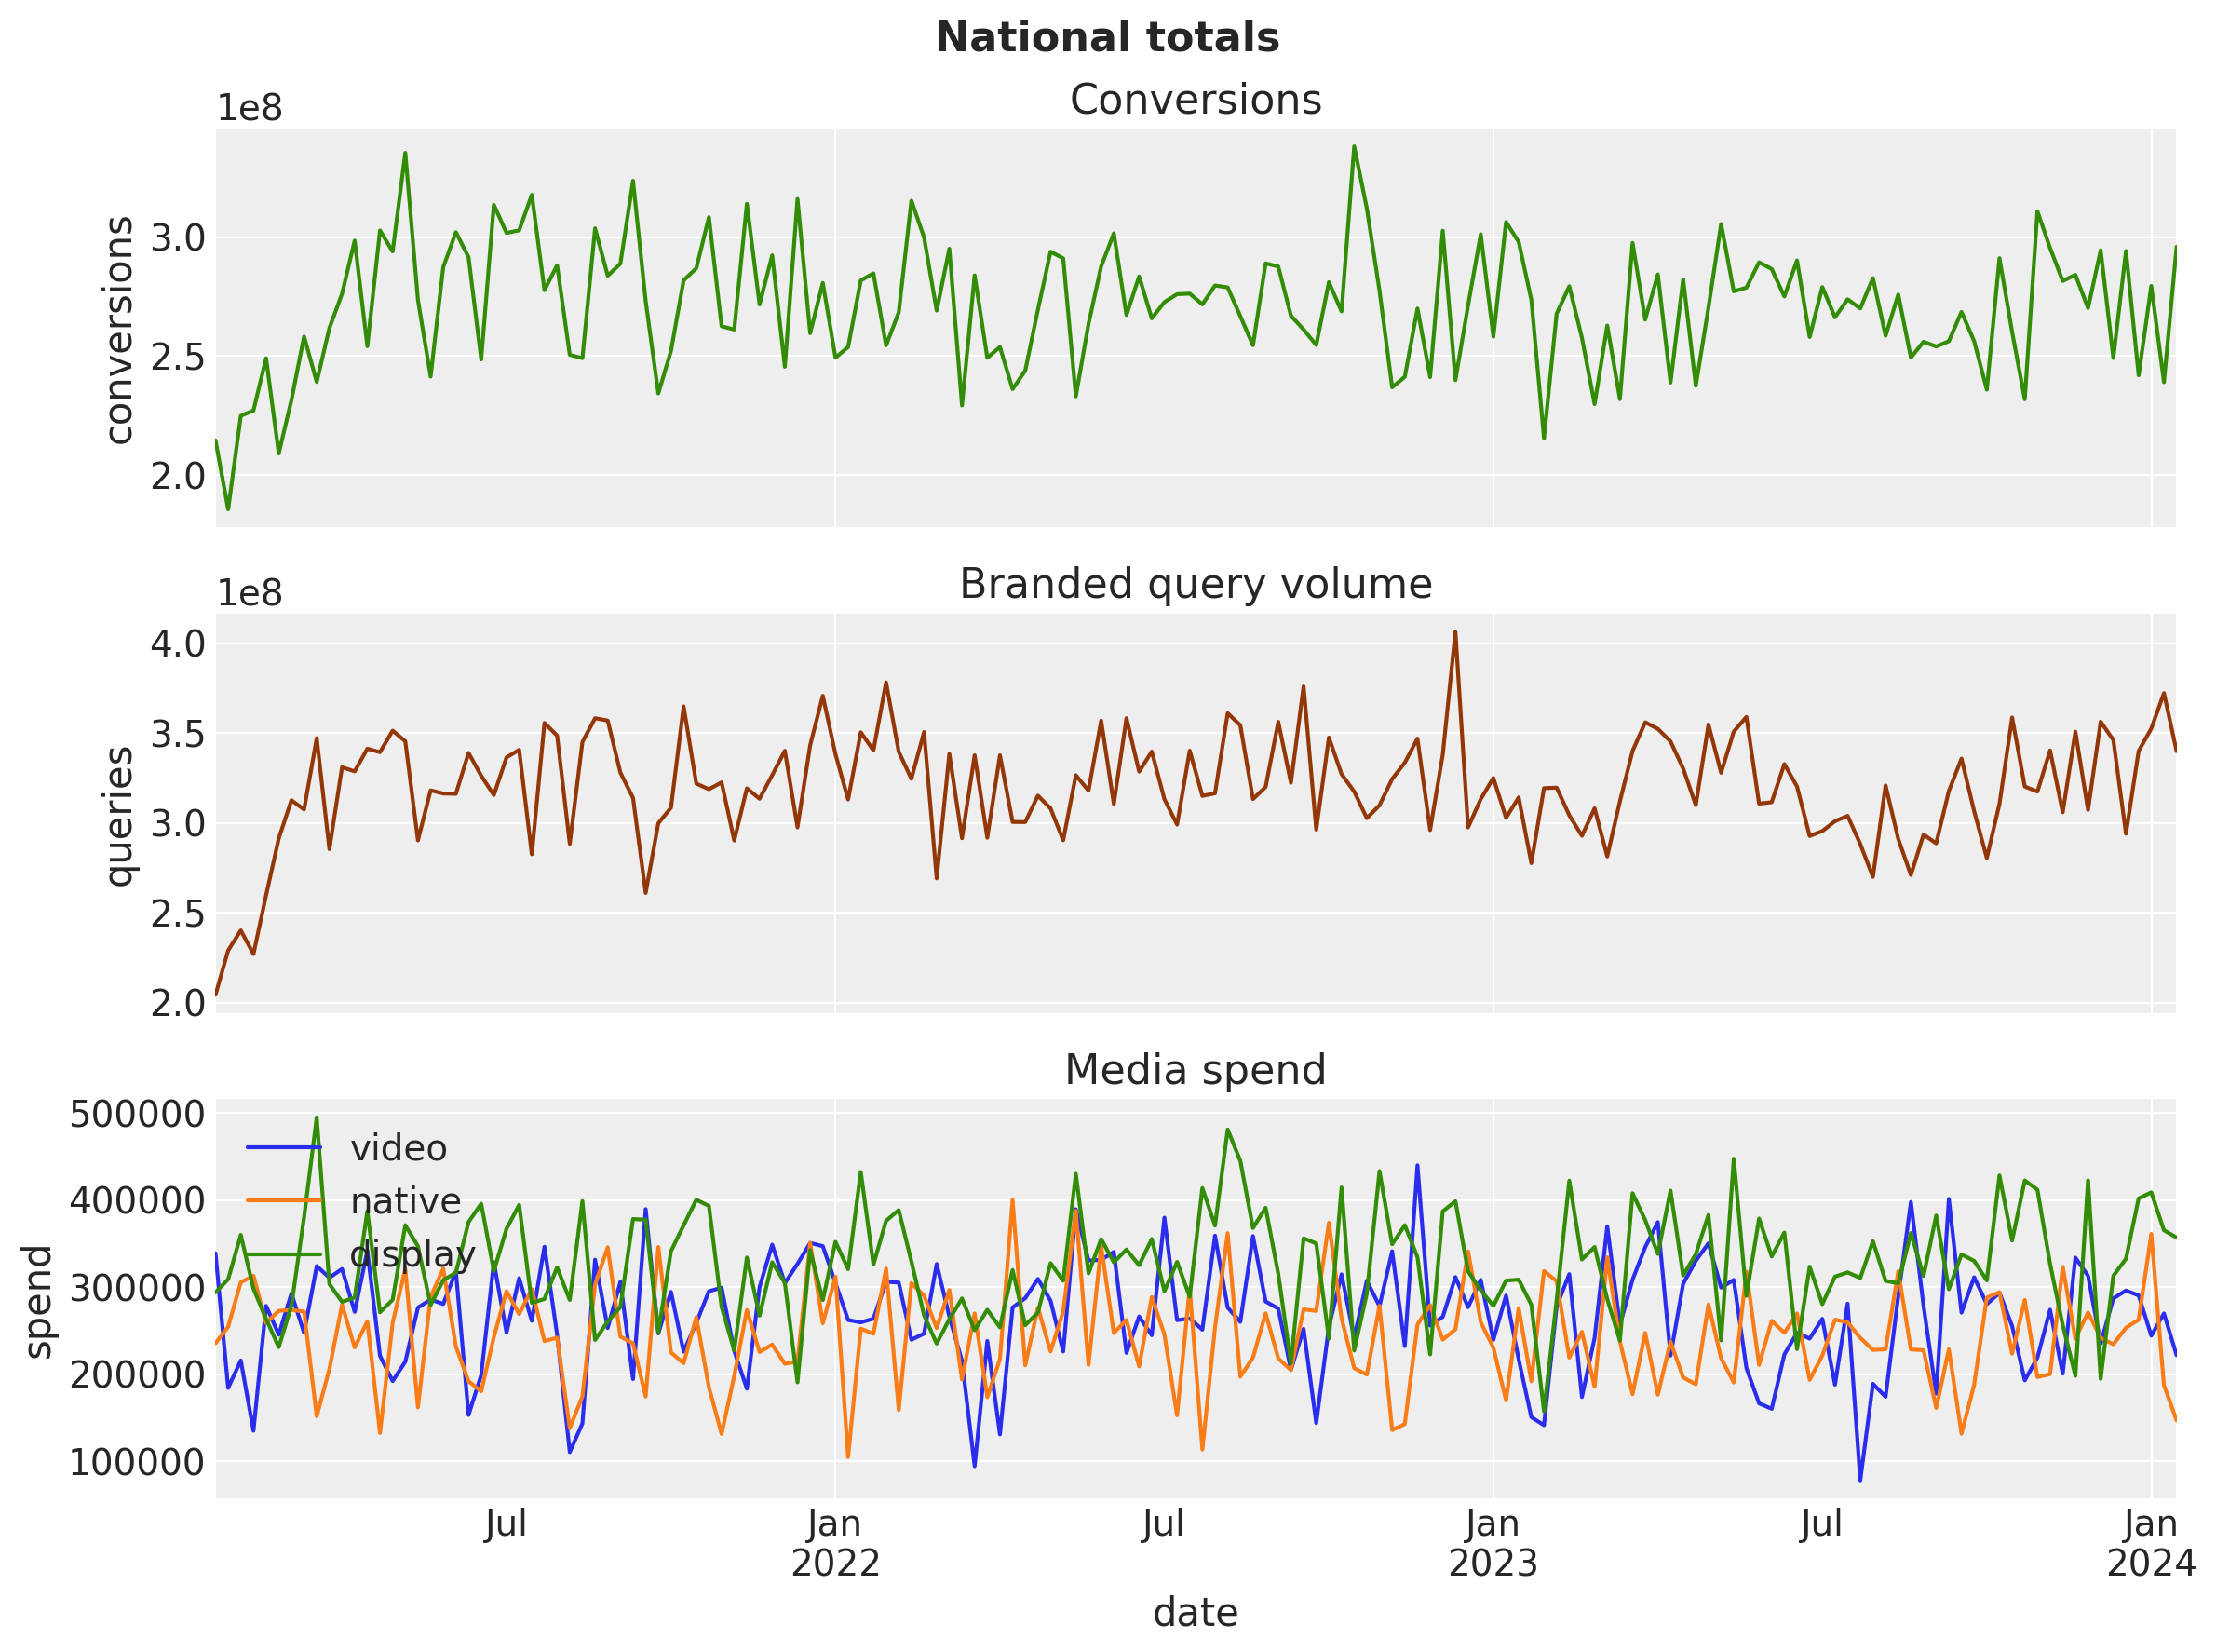

In [5]:
national = df.groupby("date")[["conversions", "branded_gqv", *channels]].sum()

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 9), sharex=True)
national["conversions"].plot(ax=axes[0], color="C2")
axes[0].set(title="Conversions", ylabel="conversions")
national["branded_gqv"].plot(ax=axes[1], color="C4")
axes[1].set(title="Branded query volume", ylabel="queries")
national[channels].plot(ax=axes[2])
axes[2].set(title="Media spend", ylabel="spend", xlabel="date")
fig.suptitle("National totals", fontsize=16, fontweight="bold")
fig.set_layout_engine("tight")

## The causal graph

Meridian's notebook describes the simulated relationships as follows: `BrandedGQV` is a **mediator** for `AwarenessVideo` and a **confounder** for the two performance channels, and `GenericGQV` confounds all media and conversions. Their notebook also notes that no confounder between the awareness channel and branded search was simulated, to keep the example simple. The graph below draws exactly those statements and nothing more.

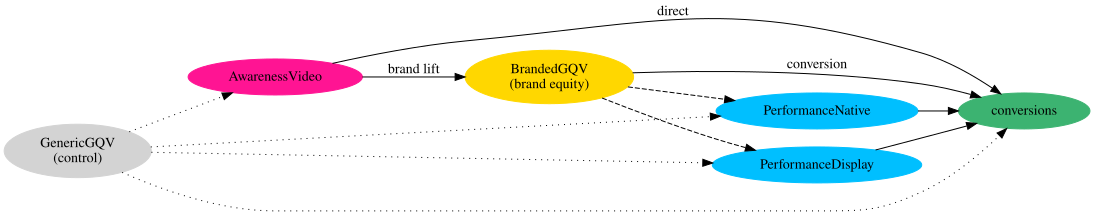

In [6]:
g = gr.Digraph()
g.attr(rankdir="LR")
g.attr("node", shape="ellipse", style="filled")
g.node("generic", "GenericGQV\n(control)", color="lightgray")
g.node("video", "AwarenessVideo", color="deeppink")
g.node("native", "PerformanceNative", color="deepskyblue")
g.node("display", "PerformanceDisplay", color="deepskyblue")
g.node("brand", "BrandedGQV\n(brand equity)", color="gold")
g.node("y", "conversions", color="mediumseagreen")

g.edge("video", "brand", label="brand lift")
g.edge("brand", "y", label="conversion")
g.edge("video", "y", label="direct")
g.edge("native", "y")
g.edge("display", "y")
g.edge("brand", "native", style="dashed")
g.edge("brand", "display", style="dashed")
for node in ["video", "native", "display", "y"]:
    g.edge("generic", node, style="dotted")
g

Solid arrows are the causal paths a model must represent. Dashed arrows are what makes branded search a confounder of the performance channels, so the conversion equation has to condition on it. Dotted arrows are the generic-search confounding, handled by a control column.

Read off the graph, the job is the same as in Meridian's two-stage setup. Video reaches conversions along two paths: directly, and through the branded search it creates. The conversion equation conditions on branded search, which blocks the confounding of the performance channels but also blocks video's indirect path. The indirect path therefore has to be modeled explicitly.

Meridian does this with two models. Stage 1 regresses branded search on video; stage 2 regresses conversions on all media with branded search as a linear organic channel; a custom analyzer adds the stage-1 effect, pushed through stage 2, to video's incremental outcome. We write the same structure as **one** model. The brand equation becomes a custom {class}`~pymc_marketing.mmm.additive_effect.MuEffect` with its own likelihood, fit jointly with the conversion equation.

## The full-funnel model

The base {class}`~pymc_marketing.mmm.mmm.MMM` is an ordinary geo-level model of conversions: the three channels with geometric adstock and logistic saturation, `generic_gqv` as a control, and yearly seasonality. The funnel lives in one additive effect with three pieces:

1. **Brand equation.** Scaled branded search in each geo is a geo-level baseline, an annual cycle, and the lift created by video spend through its own adstock and saturation:

   $$\text{brand}_{t,g} \sim \text{Normal}\big(b_g + s_1 \sin(\omega t) + s_2 \cos(\omega t) + \text{lift}_g(\text{video}^{\text{hist}})_t,\ \sigma_g\big).$$

2. **Brand counterfactual.** Under any video plan, branded search is what was observed, minus the lift history created, plus the lift the plan creates. At the historical plan the two lifts cancel and the model sees the observed series. The unexplained part of branded search is carried over unchanged, exactly as in Meridian's analyzer.

   $$\text{brand}^{\text{plan}}_{t,g} = \text{brand}_{t,g} - \text{lift}_g(\text{video}^{\text{hist}})_t + \text{lift}_g(\text{video}^{\text{plan}})_t.$$

3. **Conversion path.** The counterfactual brand series enters the conversion mean through its own adstock and a response function that is either linear (`NoSaturation`, matching Meridian's stage 2) or saturating (`LogisticSaturation`).

Because the effect reads the model's channel data through `mmm.scaled_channel`, any intervention on `channel_data`, including every candidate budget the optimizer tries, moves the brand lift and with it the conversion path. That is all the optimizer needs to price the indirect effect.

### Data plumbing

The effect needs four series that are not channels or controls: scaled branded search, historical video spend in the model's own scaled units, and the two annual harmonics. {class}`~pymc_marketing.mmm.additive_effect.DataVarMuEffect` reads them from the `xarray.Dataset` the model is built from (a `DataFrame` would drop the extra columns), and `fit` takes the equivalent long frame, as in {ref}`mmm_funnel_mueffect_advanced`.

The channel scale is each geo's maximum weekly spend, so `video_hist` divides by the same maximum. We assert that identity once the model is built.

In [7]:
L_MAX = 8
L_BRAND = 26

wide = df.set_index(["date", "geo"]).to_xarray().reindex(geo=geos)
spend_hist = wide[channels].to_array("channel").transpose("date", "geo", "channel")
video_scale = wide["video"].max("date")
branded_scale = wide["branded_gqv"].max("date")

omega_t = 2 * np.pi * np.arange(n_dates) / 52.18
ds = xr.Dataset(
    {
        "_channel": spend_hist,
        "_control": wide[["generic_gqv"]]
        .to_array("control")
        .transpose("date", "geo", "control"),
        "branded_gqv": wide["branded_gqv"] / branded_scale,
        "video_hist": wide["video"] / video_scale,
        "brand_sin": xr.DataArray(np.sin(omega_t), dims="date", coords={"date": dates}),
        "brand_cos": xr.DataArray(np.cos(omega_t), dims="date", coords={"date": dates}),
    }
)
y = wide["conversions"].transpose("date", "geo")

X_long = df[["date", "geo", *channels, "generic_gqv"]]
y_long = df["conversions"]

### The `FullFunnelEffect` component

One detail in `create_effect` deserves a comment. The brand transformation is applied twice, to the spend being evaluated and to historical spend, and both applications must share **one** set of parameters. Calling the {class}`~pymc_marketing.mmm.media_transformation.MediaTransformation` creates its priors, so the second application goes through the components' own `__call__`, which reuses the variables already in the model.

In [8]:
class FullFunnelEffect(DataVarMuEffect):
    """Video -> branded search -> conversions, fit jointly with the MMM.

    Adds the brand equation (with its own likelihood) and the conversion path of
    the counterfactual branded-search series to the target mean.
    """

    brand_transform: InstanceOf[MediaTransformation]
    conversion_transform: InstanceOf[MediaTransformation]
    channel: str = "video"

    model_config = {"arbitrary_types_allowed": True}

    def to_dict(self) -> dict:
        """Serialize the effect (transformations delegate to their own dicts)."""
        return {
            "data_vars": self.data_vars,
            "prefix": self.prefix,
            "channel": self.channel,
            "brand_transform": self.brand_transform.to_dict(),
            "conversion_transform": self.conversion_transform.to_dict(),
        }

    def incrementality_spec(self) -> IncrementalitySpec:
        """Opt in to incrementality, declaring the chained adstocks' extra reach."""
        extra_lags = (
            self.brand_transform.adstock.l_max
            - L_MAX
            + self.conversion_transform.adstock.l_max
        )
        return IncrementalitySpec(additional_carryover_lags=extra_lags)

    def create_effect(self, mmm):
        """Build the brand equation, its likelihood, and the conversion path."""
        model = mmm.model
        p = self.prefix
        bt = self.brand_transform

        # Lift under the spend being evaluated: history when fitting, a
        # candidate plan when optimizing.
        lift_now = pmd.Deterministic(
            f"{p}_brand_lift", bt(mmm.scaled_channel(self.channel), dim="date")
        )
        # Lift under historical spend, reusing the same parameters.
        lift_hist = bt.second(
            bt.first(model["video_hist"], core_dim="date"), core_dim="date"
        )

        # Brand equation: baseline + annual cycle + video lift.
        base = pmd.Normal(f"{p}_brand_intercept", mu=0.5, sigma=0.5, dims=("geo",))
        s_sin = pmd.Normal(f"{p}_brand_sin", mu=0, sigma=0.2)
        s_cos = pmd.Normal(f"{p}_brand_cos", mu=0, sigma=0.2)
        brand_mean = (
            base + s_sin * model["brand_sin"] + s_cos * model["brand_cos"] + lift_hist
        )
        pmd.Normal(
            f"{p}_brand_likelihood",
            mu=brand_mean,
            sigma=pmd.HalfNormal(f"{p}_brand_sigma", sigma=0.3, dims=("geo",)),
            observed=model["branded_gqv"],
        )

        # Counterfactual branded search under the evaluated plan.
        brand_cf = pmd.Deterministic(
            f"{p}_brand_counterfactual", model["branded_gqv"] + lift_now - lift_hist
        )
        return pmd.Deterministic(
            f"{p}_effect_contribution", self.conversion_transform(brand_cf, dim="date")
        )

The factory wires up the two transformations. The brand-lift curve is pooled across geos in its shape and free per geo in its amplitude. The only switch is the response of conversions to branded search: `NoSaturation` gives the linear mediator of Meridian's stage 2, `LogisticSaturation` lets it bend.

In [9]:
def make_effect(saturating: bool) -> FullFunnelEffect:
    """Construct the funnel effect with a linear or a saturating conversion path."""
    beta_prior = Prior("HalfNormal", sigma=1.0, dims="geo")
    conversion_response = (
        LogisticSaturation(
            prefix="sat_conv",
            priors={"lam": Prior("Gamma", mu=1.5, sigma=1.0), "beta": beta_prior},
        )
        if saturating
        else NoSaturation(prefix="sat_conv", priors={"beta": beta_prior})
    )
    return FullFunnelEffect(
        data_vars=["branded_gqv", "video_hist", "brand_sin", "brand_cos"],
        prefix="funnel",
        brand_transform=MediaTransformation(
            adstock=GeometricAdstock(
                l_max=L_BRAND,
                prefix="adstock_brand",
                priors={"alpha": Prior("Beta", alpha=2, beta=3)},
            ),
            saturation=LogisticSaturation(
                prefix="sat_brand",
                priors={
                    "lam": Prior("Gamma", mu=2.0, sigma=1.0),
                    "beta": Prior("HalfNormal", sigma=0.5, dims="geo"),
                },
            ),
            adstock_first=True,
            dims=("geo",),
        ),
        conversion_transform=MediaTransformation(
            adstock=GeometricAdstock(
                l_max=L_MAX,
                prefix="adstock_conv",
                priors={"alpha": Prior("Beta", alpha=2, beta=3)},
            ),
            saturation=conversion_response,
            adstock_first=True,
            dims=("geo",),
        ),
    )


def make_mmm(saturating: bool) -> MMM:
    """Build the base geo MMM and attach the funnel effect."""
    mmm = MMM(
        date_column="date",
        target_column="conversions",
        channel_columns=channels,
        control_columns=["generic_gqv"],
        dims=("geo",),
        scaling={
            "channel": {"method": "max", "dims": ()},
            "target": {"method": "max", "dims": ()},
        },
        adstock=GeometricAdstock(
            l_max=L_MAX,
            priors={"alpha": Prior("Beta", alpha=2, beta=3, dims="channel")},
        ),
        saturation=LogisticSaturation(
            priors={
                "lam": Prior("Gamma", mu=3.0, sigma=1.0, dims="channel"),
                "beta": Prior("HalfNormal", sigma=0.5, dims=("geo", "channel")),
            }
        ),
        yearly_seasonality=2,
        model_config={
            "intercept": Prior("Normal", mu=0.3, sigma=0.3, dims="geo"),
            "gamma_control": Prior("Normal", mu=0, sigma=0.3, dims=("geo", "control")),
            "gamma_fourier": Prior(
                "Normal", mu=0, sigma=0.1, dims=("geo", "fourier_mode")
            ),
            "likelihood": Prior(
                "Normal",
                sigma=Prior("HalfNormal", sigma=0.3, dims="geo"),
                dims=("date", "geo"),
            ),
        },
        sampler_config={"nuts_sampler": "nutpie"},
    )
    mmm.add_mu_effect(make_effect(saturating))
    return mmm

## Fitting

We build each model from the `Dataset` (a fresh copy each time, since building attaches the target to it) and fit on the long frame. Both variants share every prior except the conversion response.

In [10]:
SAMPLE_KWARGS = {"chains": 4, "tune": 1_000, "draws": 500, "target_accept": 0.9}

models: dict[str, MMM] = {}
for label, saturating in [("linear", False), ("saturating", True)]:
    mmm = make_mmm(saturating)
    mmm.build_model(X=ds.copy(), y=y)
    mmm.add_original_scale_contribution_variable(
        var=["channel_contribution", "funnel_effect_contribution", "y"]
    )
    channel_scale = mmm.model["channel_scale"].get_value()
    np.testing.assert_allclose(
        np.asarray(channel_scale)[..., channels.index("video")], video_scale.values
    )
    mmm.fit(X=X_long, y=y_long, random_seed=rng, **SAMPLE_KWARGS)
    pm.compute_log_likelihood(
        mmm.idata,
        var_names=["y"],
        model=mmm.model,
        extend_inferencedata=True,
        progressbar=False,
    )
    models[label] = mmm

NUTS[nutpie]: [y_sigma, adstock_conv_alpha, adstock_brand_alpha, sat_brand_lam, sat_brand_beta, sat_conv_beta, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, funnel_brand_sigma, funnel_brand_cos, funnel_brand_sin, funnel_brand_intercept]


Output()

Output()

NUTS[nutpie]: [y_sigma, adstock_conv_alpha, adstock_brand_alpha, sat_brand_lam, sat_brand_beta, sat_conv_lam, sat_conv_beta, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, funnel_brand_sigma, funnel_brand_cos, funnel_brand_sin, funnel_brand_intercept]


Output()

Output()

### Diagnostics

In [11]:
KEY_PARAMS = [
    "adstock_alpha",
    "saturation_lam",
    "adstock_brand_alpha",
    "sat_brand_lam",
    "adstock_conv_alpha",
]

rows = {}
for label, mmm in models.items():
    summary = az.summary(mmm.idata, var_names=[*KEY_PARAMS, "sat_conv_beta"])
    rows[label] = {
        "divergences": int(mmm.idata["sample_stats"]["diverging"].sum()),
        "max r_hat": float(summary["r_hat"].max()),
        "min ess_bulk": float(summary["ess_bulk"].min()),
        "min ess_tail": float(summary["ess_tail"].min()),
    }
pd.DataFrame(rows).T

,divergences,max r_hat,min ess_bulk,min ess_tail
linear,0.0,1.01,421.0,307.0
saturating,0.0,1.01,820.0,533.0


In [12]:
az.summary(
    models["saturating"].idata, var_names=[*KEY_PARAMS, "sat_conv_lam"], kind="stats"
)

,mean,sd,eti89_lb,eti89_ub
adstock_alpha[video],0.85,0.11,0.65,0.96
adstock_alpha[native],0.55,0.084,0.42,0.68
adstock_alpha[display],0.93,0.039,0.85,0.98
saturation_lam[video],0.24,0.098,0.11,0.41
saturation_lam[native],0.37,0.11,0.22,0.57
saturation_lam[display],0.54,0.17,0.31,0.85
adstock_brand_alpha,0.82,0.0053,0.81,0.83
sat_brand_lam,3.7,0.26,3.3,4.1
adstock_conv_alpha,0.88,0.039,0.81,0.94
sat_conv_lam,0.46,0.084,0.34,0.6


DIAGNOSTICS_PLACEHOLDER

### Linear or saturating mediator?

Both models make the same claim about every quantity except the shape of the conversion response to branded search, so leave-one-out cross-validation on the conversion likelihood is a fair referee.

In [13]:
az.compare({label: mmm.idata for label, mmm in models.items()}, var_name="y")

/home/appuser/app/.venv/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


/home/appuser/app/.venv/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
linear,0,0.0,0.0,NaN,,2 k̂ > 0.70,170.0,4530.0,37.0,1.0
saturating,1,-2.0,1.3,0.88,|elpd_diff| < 4,2 k̂ > 0.70,170.0,4530.0,37.0,0.0


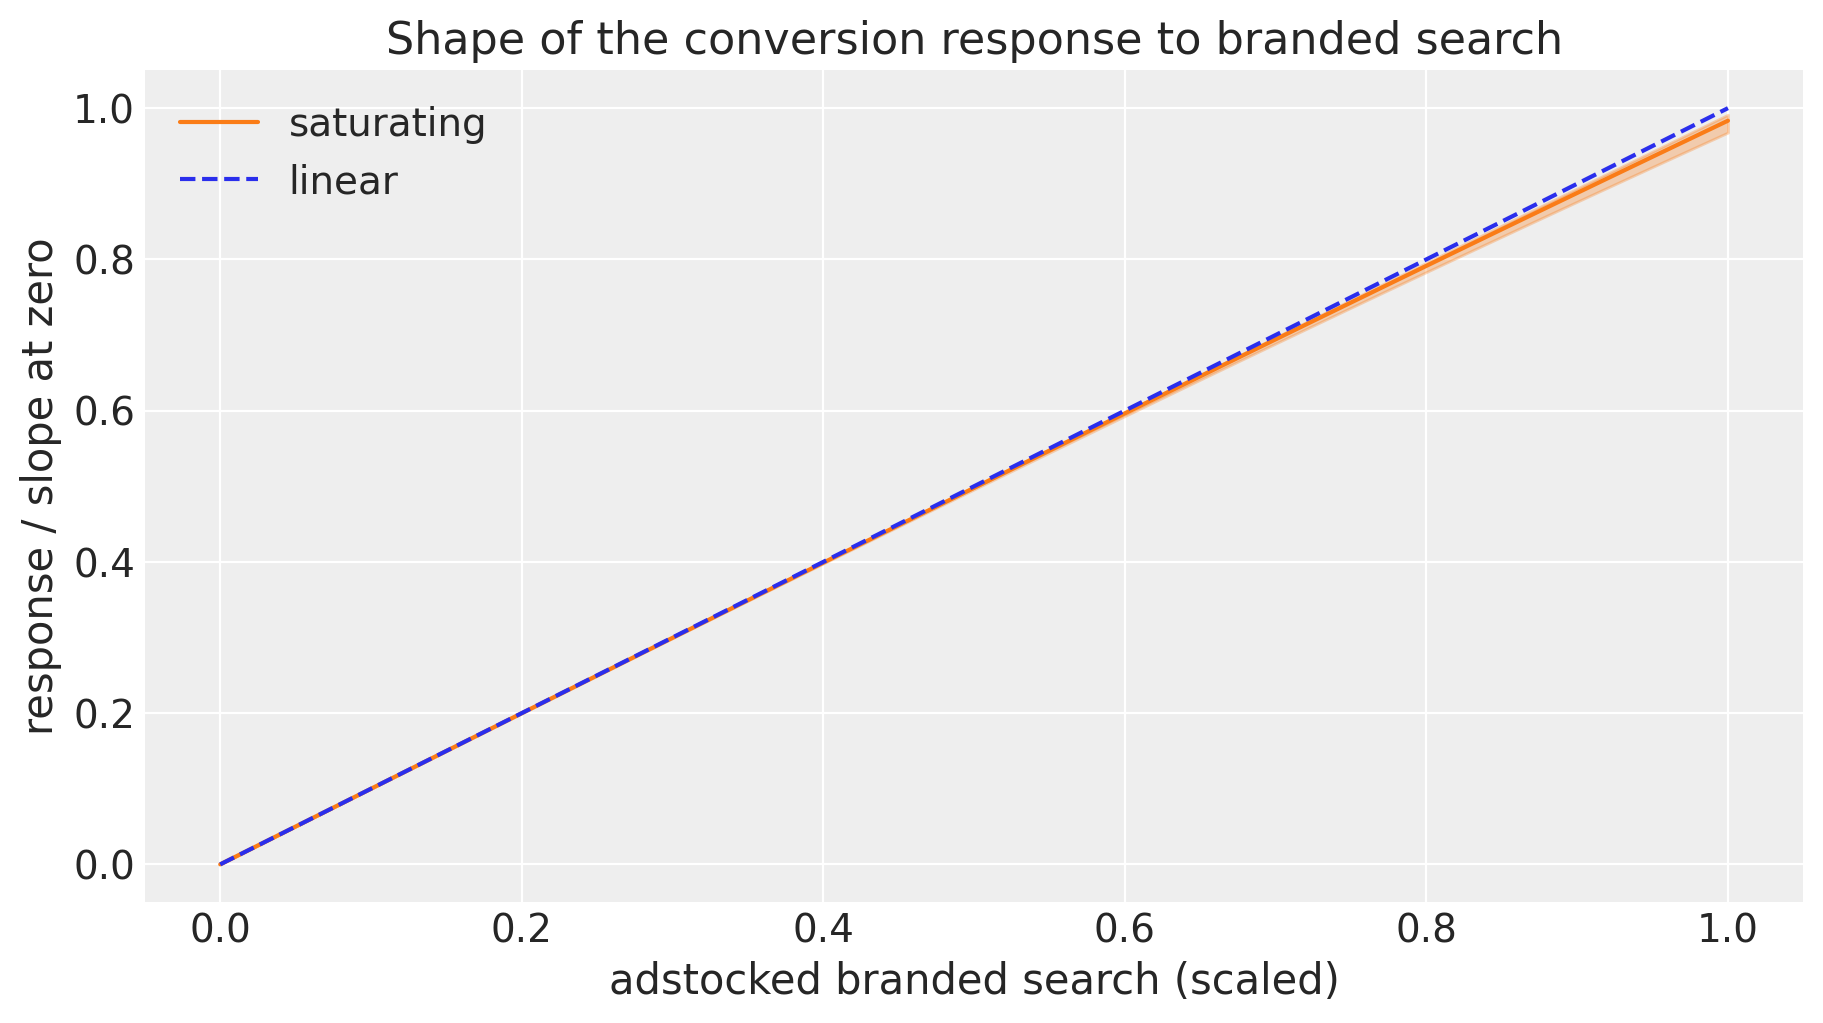

In [14]:
lam = models["saturating"].idata["posterior"]["sat_conv_lam"]
brand_cf_max = float(
    models["saturating"].idata["posterior"]["funnel_brand_counterfactual"].max()
)
x_grid = np.linspace(0, brand_cf_max, 100)

fig, ax = plt.subplots(figsize=(9, 5))
curves = (1 - np.exp(-lam.values.reshape(-1, 1) * x_grid)) / (
    1 + np.exp(-lam.values.reshape(-1, 1) * x_grid)
)
# Normalise each draw by its slope at zero (lam / 2) so curvature is comparable.
curves = curves / (lam.values.reshape(-1, 1) / 2)
ax.plot(x_grid, np.percentile(curves, 50, axis=0), color="C1", label="saturating")
ax.fill_between(
    x_grid,
    np.percentile(curves, 3, axis=0),
    np.percentile(curves, 97, axis=0),
    color="C1",
    alpha=0.3,
)
ax.plot(x_grid, x_grid, color="C0", linestyle="--", label="linear")
ax.set(
    xlabel="adstocked branded search (scaled)",
    ylabel="response / slope at zero",
    title="Shape of the conversion response to branded search",
)
ax.legend()

LOO_PLACEHOLDER

## What the funnel is worth

Before optimizing anything we ask the question the funnel exists for: how much of video's effect on conversions travels through branded search? We answer it with the optimizer's own machinery, which already knows how to evaluate the model under any spend plan. A plan is a weekly budget per geo and channel, spread over the weeks with each cell's historical pattern, so the historical plan reproduces the training data exactly.

In [15]:
mean_plan = spend_hist.mean("date")
total_budget = float(mean_plan.sum())
budget_pattern = spend_hist / spend_hist.sum("date")
budget_bounds = xr.concat(
    [0.7 * mean_plan, 1.3 * mean_plan],
    dim=pd.Index(["lower", "upper"], name="bound"),
)

RESPONSES = {
    "direct": "channel_contribution_original_scale",
    "mediated": "funnel_effect_contribution_original_scale",
    "total": "total_response_original_scale",
}


# The objective graph contains the adstock convolution, which numba cannot compile and
# runs in object mode, where the convolution's scalar mode flag arrives broadcast to
# shape (1, 1) and fails a scalar check. The C virtual machine compiles the same graph.
OPT_MODE = Mode(linker="cvm", optimizer="fast_run")

# Every objective evaluation runs the model forward for all posterior draws, and the
# optimizer needs hundreds of them, so the plans are optimized on a thinned posterior.
OPT_THIN = 8


def make_optimizer(mmm: MMM, idata=None, utility_function=None) -> BudgetOptimizer:
    """In-sample optimizer over the training window with the historical weekly pattern."""
    carryover_lags = mmm.effective_carryover_lags()
    opt_model = mmm.create_optimization_model(
        start_date=dates[0], end_date=dates[-(carryover_lags + 1)]
    )
    if len(opt_model.coords["date"]) != n_dates:
        raise ValueError("the optimization window does not match the training dates")
    kwargs = {} if utility_function is None else {"utility_function": utility_function}
    return BudgetOptimizer(
        model=opt_model,
        idata=(mmm.idata if idata is None else idata).isel(
            draw=slice(None, None, OPT_THIN)
        ),
        num_periods=n_dates,
        adstock_periods=0,
        response_variable="total_response_original_scale",
        budget_distribution_over_period=budget_pattern,
        compile_kwargs={"mode": OPT_MODE},
        **kwargs,
    )


def response_samples(optimizer: BudgetOptimizer, plan: xr.DataArray, part: str):
    """Posterior samples of a response summed over everything but the draws."""
    samples = optimizer.evaluate_response_distribution(plan, RESPONSES[part])
    other_dims = [dim for dim in samples.dims if dim != "sample"]
    return samples.sum(other_dims) if other_dims else samples


optimizers = {label: make_optimizer(mmm) for label, mmm in models.items()}

# The historical plan reproduces the fitted posterior exactly.
for label, mmm in models.items():
    np.testing.assert_allclose(
        response_samples(optimizers[label], mean_plan, "total").mean(),
        mmm.idata["posterior"]["total_response_original_scale"]
        .isel(draw=slice(None, None, OPT_THIN))
        .mean(),
        rtol=1e-6,
    )

Video's in-sample effect is the response under the historical plan minus the response with video switched off in every geo, per posterior draw. Split by path and divided by video's spend over the window, it gives incremental conversions per unit of spend.

In [16]:
video_off = mean_plan.copy()
video_off.loc[{"channel": "video"}] = 0.0
video_spend = float(spend_hist.sel(channel="video").sum())


def video_effect(optimizer: BudgetOptimizer) -> xr.Dataset:
    """Per-draw incremental conversions per unit of video spend, by path."""
    return xr.Dataset(
        {
            part: (
                response_samples(optimizer, mean_plan, part)
                - response_samples(optimizer, video_off, part)
            )
            / video_spend
            for part in RESPONSES
        }
    )


def hdi_row(samples: xr.DataArray, prob: float = 0.94) -> dict[str, float]:
    """Mean, HDI bounds and HDI width of a one-dimensional sample."""
    lo, hi = az.hdi(np.asarray(samples), prob=prob)
    return {"mean": float(samples.mean()), "hdi_3%": lo, "hdi_97%": hi, "width": hi - lo}


video_effects = {label: video_effect(opt) for label, opt in optimizers.items()}
pd.DataFrame(
    {
        (label, part): hdi_row(effect[part])
        for label, effect in video_effects.items()
        for part in RESPONSES
    }
).T.style.format("{:.4f}").set_caption(
    "Video: incremental conversions per unit of spend, in-sample (94% HDI)"
)

VIDEO_EFFECT_PLACEHOLDER

## Uncertainty propagation: joint posterior versus plug-in

A chained two-model workflow has to decide what to pass from the first model to the second. The cheapest choice is a point estimate: fit stage 1, take its posterior mean, and treat the brand lift as known when pricing the funnel. The joint model makes the cost of that shortcut easy to measure. We keep the saturating model's posterior unchanged except for the three brand-lift parameters, which we fix at their posterior means in every draw. Everything downstream of the brand lift is evaluated as before, so any difference in the results is the first-stage uncertainty that the shortcut drops.

```{note}
This plug-in is an illustration of a shortcut, not a reproduction of Meridian. Meridian's analyzer pairs stage-1 draw $i$ with stage-2 draw $i$, so first-stage uncertainty does reach its outcome intervals. What the two-stage fit cannot carry is the *dependence* between the stages: the stage-1 posterior never sees conversions, and the stage-2 posterior never sees branded search as an outcome. The joint model learns both from both.
```

In [17]:
BRAND_PARAMS = ["adstock_brand_alpha", "sat_brand_lam", "sat_brand_beta"]


def plug_in(idata, names: list[str]):
    """Copy of ``idata`` with the named posterior variables fixed at their means."""
    posterior = idata["posterior"].to_dataset()
    for name in names:
        posterior[name] = (
            posterior[name].mean(("chain", "draw")).broadcast_like(posterior[name])
        )
    frozen = idata.copy()
    frozen["posterior"] = posterior
    return frozen


idata_plugin = plug_in(models["saturating"].idata, BRAND_PARAMS)
optimizers["plug-in"] = make_optimizer(models["saturating"], idata=idata_plugin)
video_effects["plug-in"] = video_effect(optimizers["plug-in"])

effect_table = pd.DataFrame(
    {
        (label, part): hdi_row(video_effects[label][part])
        for label in ["saturating", "plug-in"]
        for part in ["mediated", "total"]
    }
).T
effect_table.style.format("{:.4f}").set_caption(
    "Video incremental conversions per unit of spend: joint vs plug-in (94% HDI)"
)

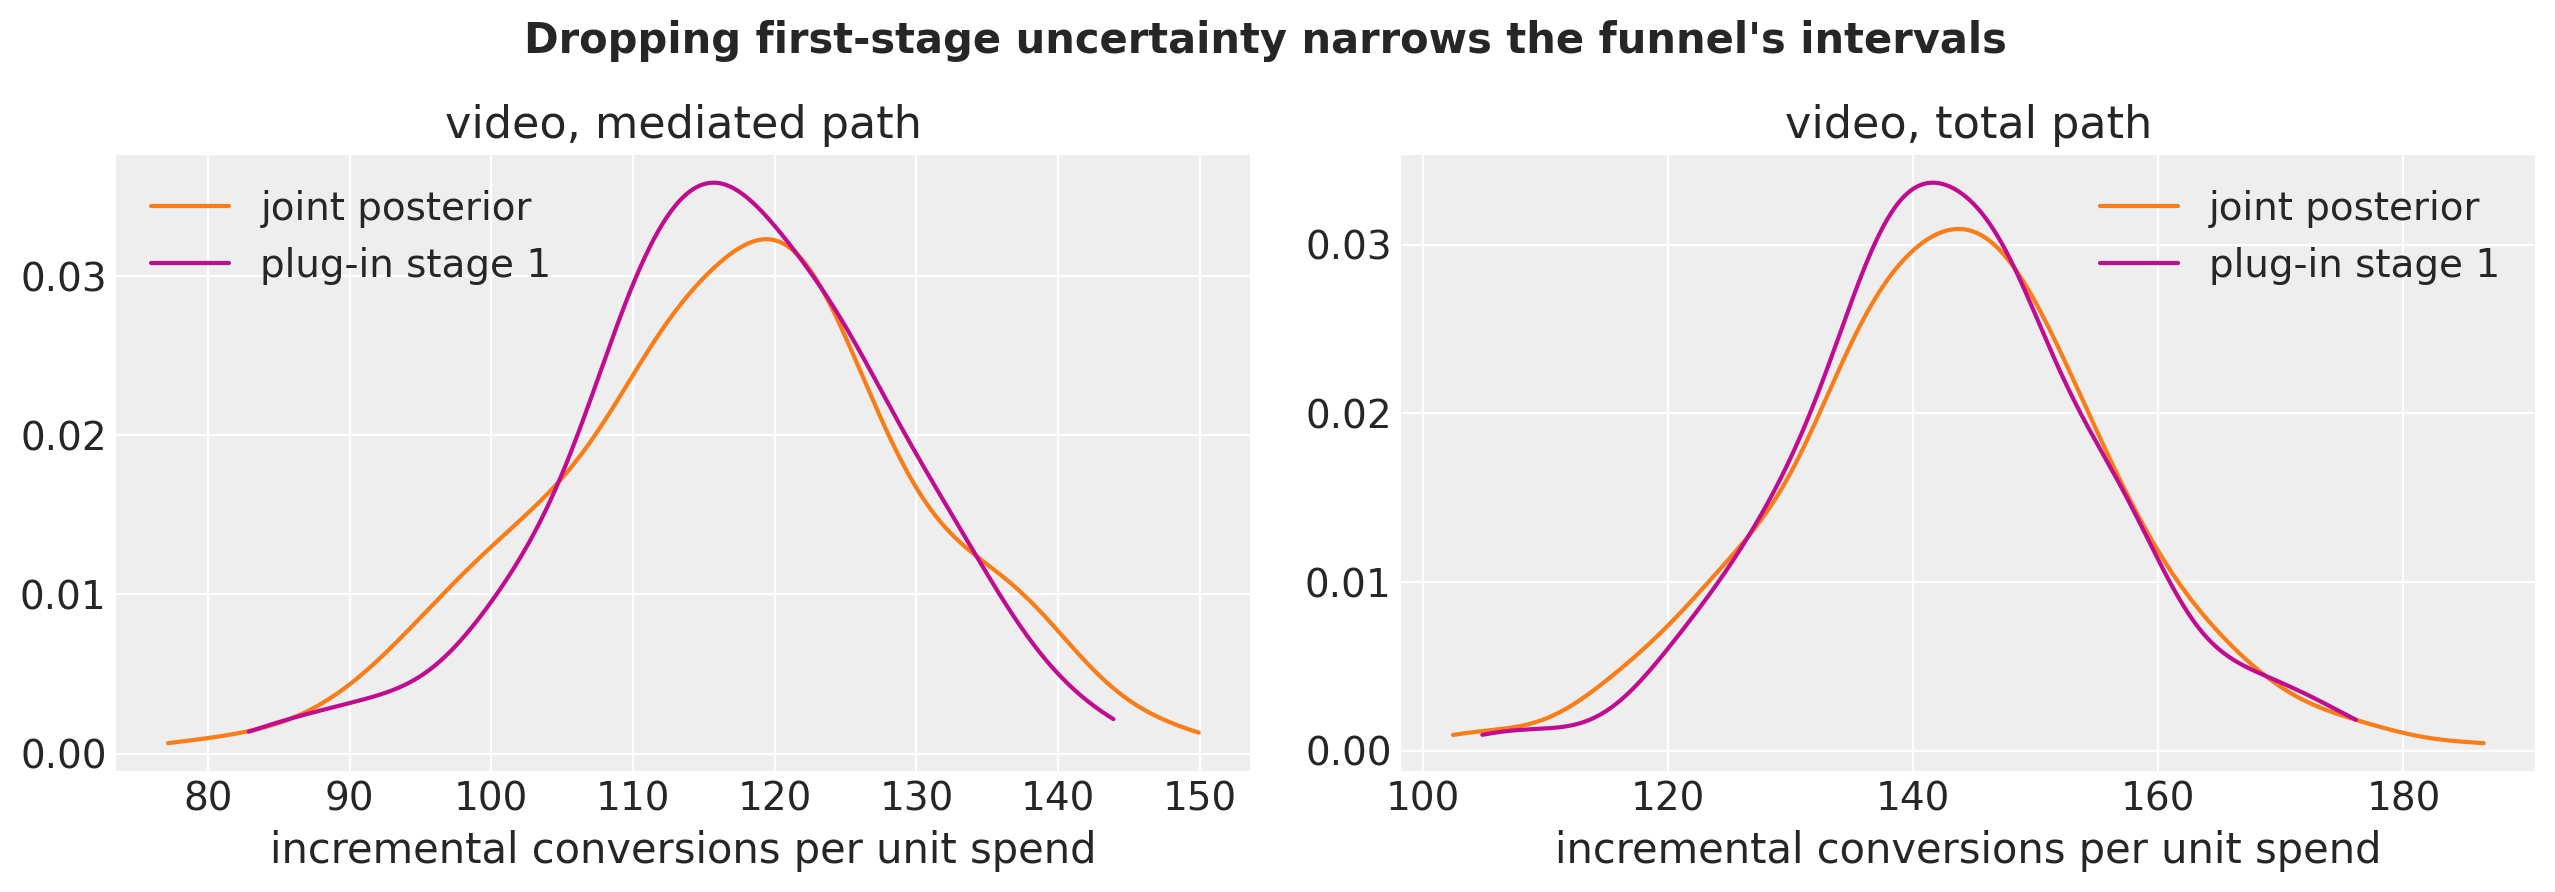

In [18]:
def plot_density(samples, ax, **kwargs) -> None:
    """Gaussian kernel density of a one-dimensional sample."""
    values = np.asarray(samples).ravel()
    grid = np.linspace(values.min(), values.max(), 512)
    ax.plot(grid, gaussian_kde(values)(grid), **kwargs)


fig, axes = plt.subplots(ncols=2, figsize=(13, 4.5))
for ax, part in zip(axes, ["mediated", "total"], strict=True):
    for label, color in [("saturating", "C1"), ("plug-in", "C3")]:
        plot_density(
            video_effects[label][part],
            ax=ax,
            color=color,
            label="joint posterior" if label == "saturating" else "plug-in stage 1",
        )
    ax.set(title=f"video, {part} path", xlabel="incremental conversions per unit spend")
    ax.legend()
fig.suptitle(
    "Dropping first-stage uncertainty narrows the funnel's intervals",
    fontsize=15,
    fontweight="bold",
)
fig.set_layout_engine("tight")

PLUGIN_EFFECT_PLACEHOLDER

## Budget optimization

We now optimize. The setup follows {ref}`mmm_funnel_mueffect_advanced`: in-sample, over the training window, at the historical total weekly budget, with each geo $\times$ channel cell free to move within $\pm 30\%$ of its historical weekly mean (Meridian's default bound, here applied per cell instead of per national channel) and each cell's historical week-by-week pattern kept fixed. The objective is `total_response_original_scale`, which includes the funnel's conversion path. The default objective scores the direct path only and would not see the brand effect at all.

We run four optimizations:

- `linear`: the joint model with a linear mediator, mean objective.
- `saturating`: the joint model with a saturating mediator, mean objective.
- `plug-in`: the saturating model with the brand lift fixed at point estimates, mean objective.
- `saturating, CVaR`: the saturating model with a risk-aware objective, the conditional value at risk of the *gain* over the historical plan at the 10% tail.

The risk-aware objective is defined on the per-draw gain rather than on the response level, because the baseline (intercept, seasonality, controls) is the same under every plan in a given draw. Subtracting the historical plan's response draw by draw removes it, so the tail the objective looks at is the tail of what the reallocation itself is worth.

A word on why saturation is not a problem for the optimizer. Every link from spend to conversions in this model, adstock, the brand-lift curve and the conversion response, is linear or concave and non-decreasing. A composition of such functions is concave, and so is its average over posterior draws. The mean objective is therefore concave in the budgets with a saturating mediator just as with a linear one, and a local optimum is the global one.

In [19]:
hist_total = response_samples(optimizers["saturating"], mean_plan, "total")


def cvar_of_gain(confidence_level: float = 0.9):
    """CVaR of the per-draw gain over the historical plan."""
    cvar = conditional_value_at_risk(confidence_level)
    baseline = as_xtensor(hist_total.values, dims=("sample",))

    def _utility(samples, budgets):
        return cvar(samples - baseline, budgets)

    return _utility


optimizers["saturating, CVaR"] = make_optimizer(
    models["saturating"], utility_function=cvar_of_gain(0.9)
)

# Marginal returns are near-constant over the feasible region (see the response curves
# below), so the objective is close to linear there and SLSQP cannot find a descent step
# that satisfies a tight convergence tolerance.
minimize_kwargs = {"options": {"ftol": 1e-2, "maxiter": 2_000}}
allocations = {}
for label in ["linear", "saturating", "plug-in", "saturating, CVaR"]:
    result = optimizers[label].allocate_budget(
        total_budget=total_budget,
        budget_bounds=budget_bounds,
        x0=mean_plan,
        minimize_kwargs=minimize_kwargs,
    )
    if not result.scipy_result.success:
        raise RuntimeError(f"{label}: {result.scipy_result.message}")
    np.testing.assert_allclose(result.budgets.sum(), total_budget, rtol=1e-6)
    allocations[label] = result
    print(f"{label}: {result.scipy_result.message} ({result.scipy_result.nit} iterations)")

linear: Optimization terminated successfully (30 iterations)


saturating: Optimization terminated successfully (22 iterations)


plug-in: Optimization terminated successfully (22 iterations)


saturating, CVaR: Optimization terminated successfully (100 iterations)


In [20]:
national_mult = pd.DataFrame(
    {
        label: (
            allocations[label].budgets.sum("geo") / mean_plan.sum("geo")
        ).to_pandas()
        for label in allocations
    }
)
national_mult.style.format("{:.3f}").set_caption(
    "Optimal national weekly spend per channel, as a multiple of history"
)

,linear,saturating,plug-in,"saturating, CVaR"
channel,,,,
video,1.266,1.245,1.246,1.176
native,0.847,0.839,0.839,0.847
display,0.896,0.919,0.919,0.971


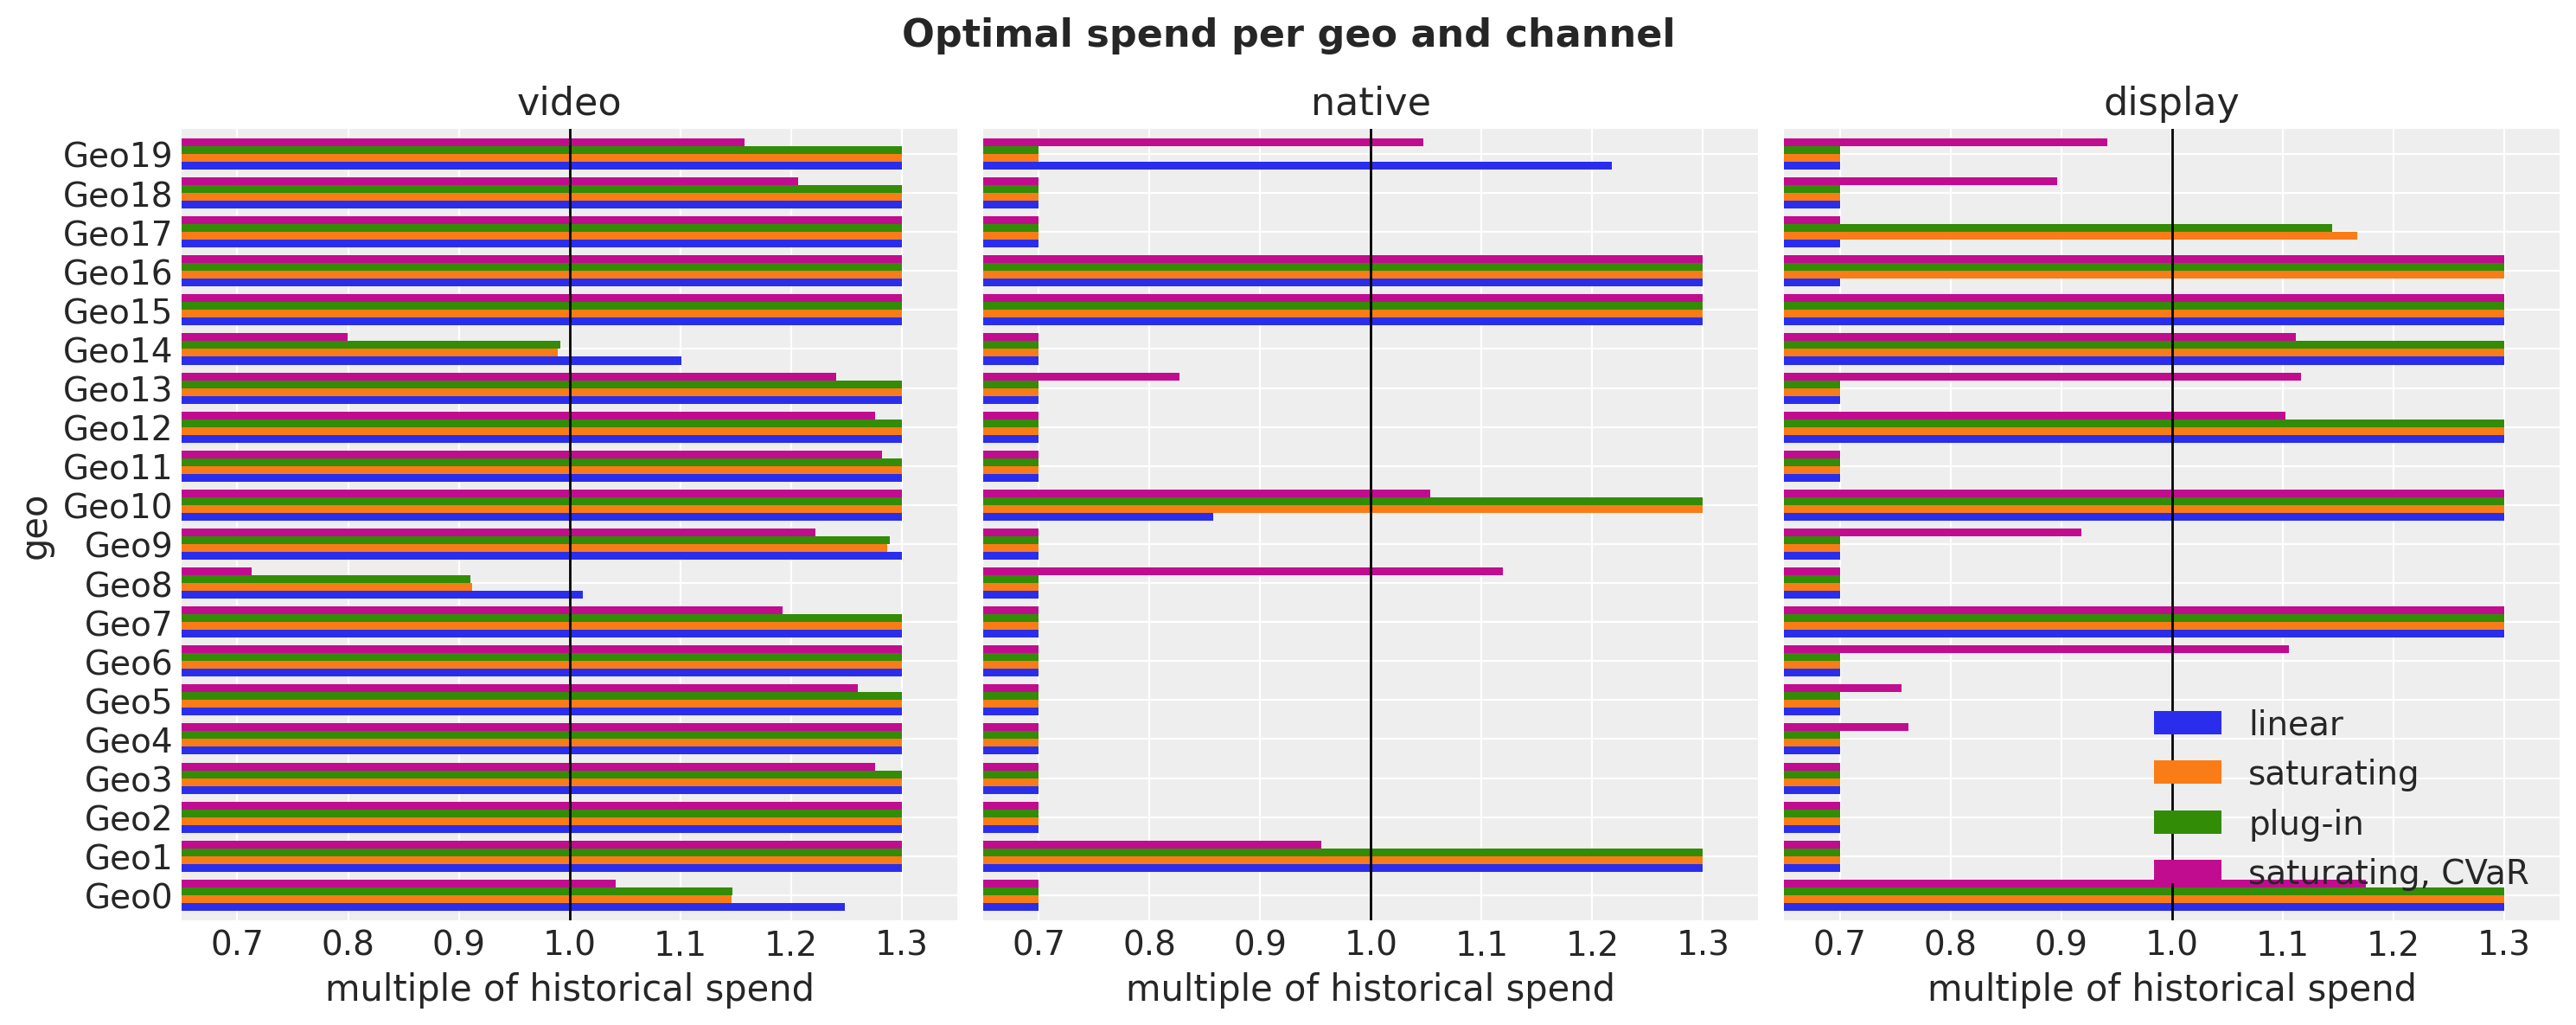

In [21]:
fig, axes = plt.subplots(ncols=len(channels), figsize=(15, 6), sharey=True)
for ax, channel in zip(axes, channels, strict=True):
    per_geo = pd.DataFrame(
        {
            label: (allocations[label].budgets / mean_plan)
            .sel(channel=channel)
            .to_pandas()
            for label in allocations
        }
    )
    per_geo.plot.barh(ax=ax, width=0.8, legend=channel == channels[-1])
    ax.axvline(1.0, color="black", linewidth=1)
    ax.set(title=channel, xlabel="multiple of historical spend", xlim=(0.65, 1.35))
fig.suptitle(
    "Optimal spend per geo and channel", fontsize=16, fontweight="bold"
)
fig.set_layout_engine("tight")

ALLOCATION_PLACEHOLDER

### Scoring the plans on the joint posterior

Each plan is scored by the gain in total conversions over the historical plan, draw by draw, under the saturating joint posterior. Because the baseline is identical under both plans within a draw, the gain is a posterior distribution of what the reallocation is worth. For the plug-in plan we also show what the plug-in posterior itself *believes* the plan is worth.

In [22]:
reference = optimizers["saturating"]


def gain(optimizer: BudgetOptimizer, plan: xr.DataArray) -> xr.DataArray:
    """Per-draw gain in total conversions of a plan over the historical plan."""
    return response_samples(optimizer, plan, "total") - response_samples(
        optimizer, mean_plan, "total"
    )


gains = {label: gain(reference, allocations[label].budgets) for label in allocations}
gains["plug-in (self-assessed)"] = gain(
    optimizers["plug-in"], allocations["plug-in"].budgets
)

gain_rows = {}
for label, samples in gains.items():
    row = hdi_row(samples)
    row["P(gain > 0)"] = float((samples > 0).mean())
    row["10% CVaR"] = float(samples.where(samples <= samples.quantile(0.1)).mean())
    gain_rows[label] = row
gain_table = pd.DataFrame(gain_rows).T
gain_table.style.format("{:.1f}").format("{:.1%}", subset=["P(gain > 0)"]).set_caption(
    "Gain in total conversions over the historical plan, scored on the joint posterior"
)

,mean,hdi_3%,hdi_97%,width,P(gain > 0),10% CVaR
linear,615993175.6,248847853.9,954973046.4,706125192.4,100.0%,269051017.4
saturating,632467445.8,267175938.3,980830142.6,713654204.3,100.0%,269748148.5
plug-in,632465603.9,266961951.6,980782892.6,713820941.0,100.0%,269869110.5
"saturating, CVaR",555894102.3,322110675.0,820085578.4,497974903.5,100.0%,350917609.2
plug-in (self-assessed),635307154.5,263687251.7,962588268.8,698901017.1,100.0%,282437566.0


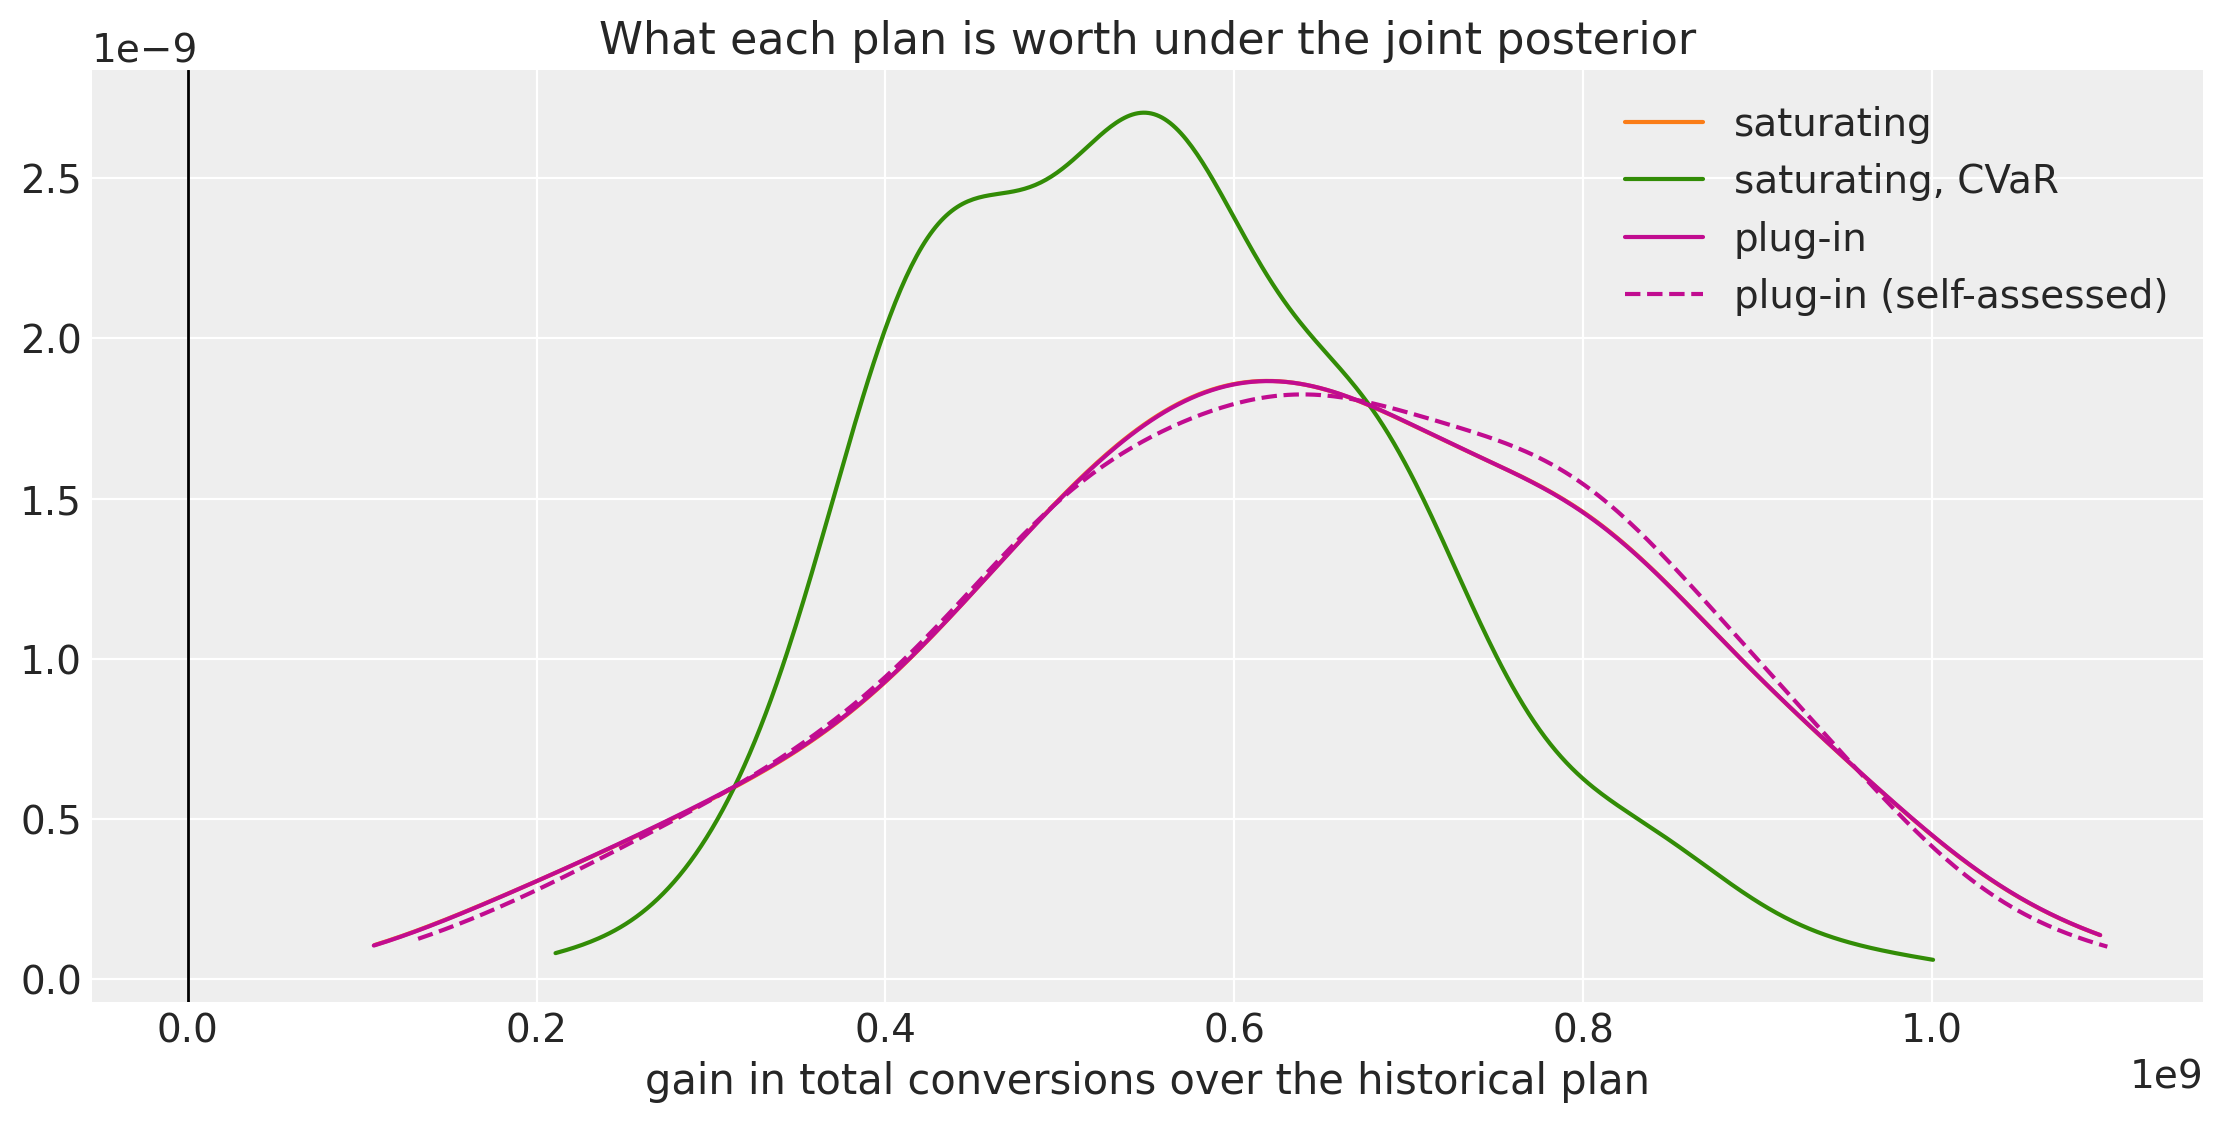

In [23]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for label, color, style in [
    ("saturating", "C1", "-"),
    ("saturating, CVaR", "C2", "-"),
    ("plug-in", "C3", "-"),
    ("plug-in (self-assessed)", "C3", "--"),
]:
    plot_density(gains[label], ax=ax, color=color, linestyle=style, label=label)
ax.axvline(0, color="black", linewidth=1)
ax.set(
    xlabel="gain in total conversions over the historical plan",
    title="What each plan is worth under the joint posterior",
)
ax.legend()

GAIN_PLACEHOLDER

## Response curves: what saturation buys

The last comparison is the one the linear restriction is about. We scale video spend in every geo by a common multiplier, holding the performance channels at history, and trace video's total effect (direct plus mediated) relative to zero video under each model.

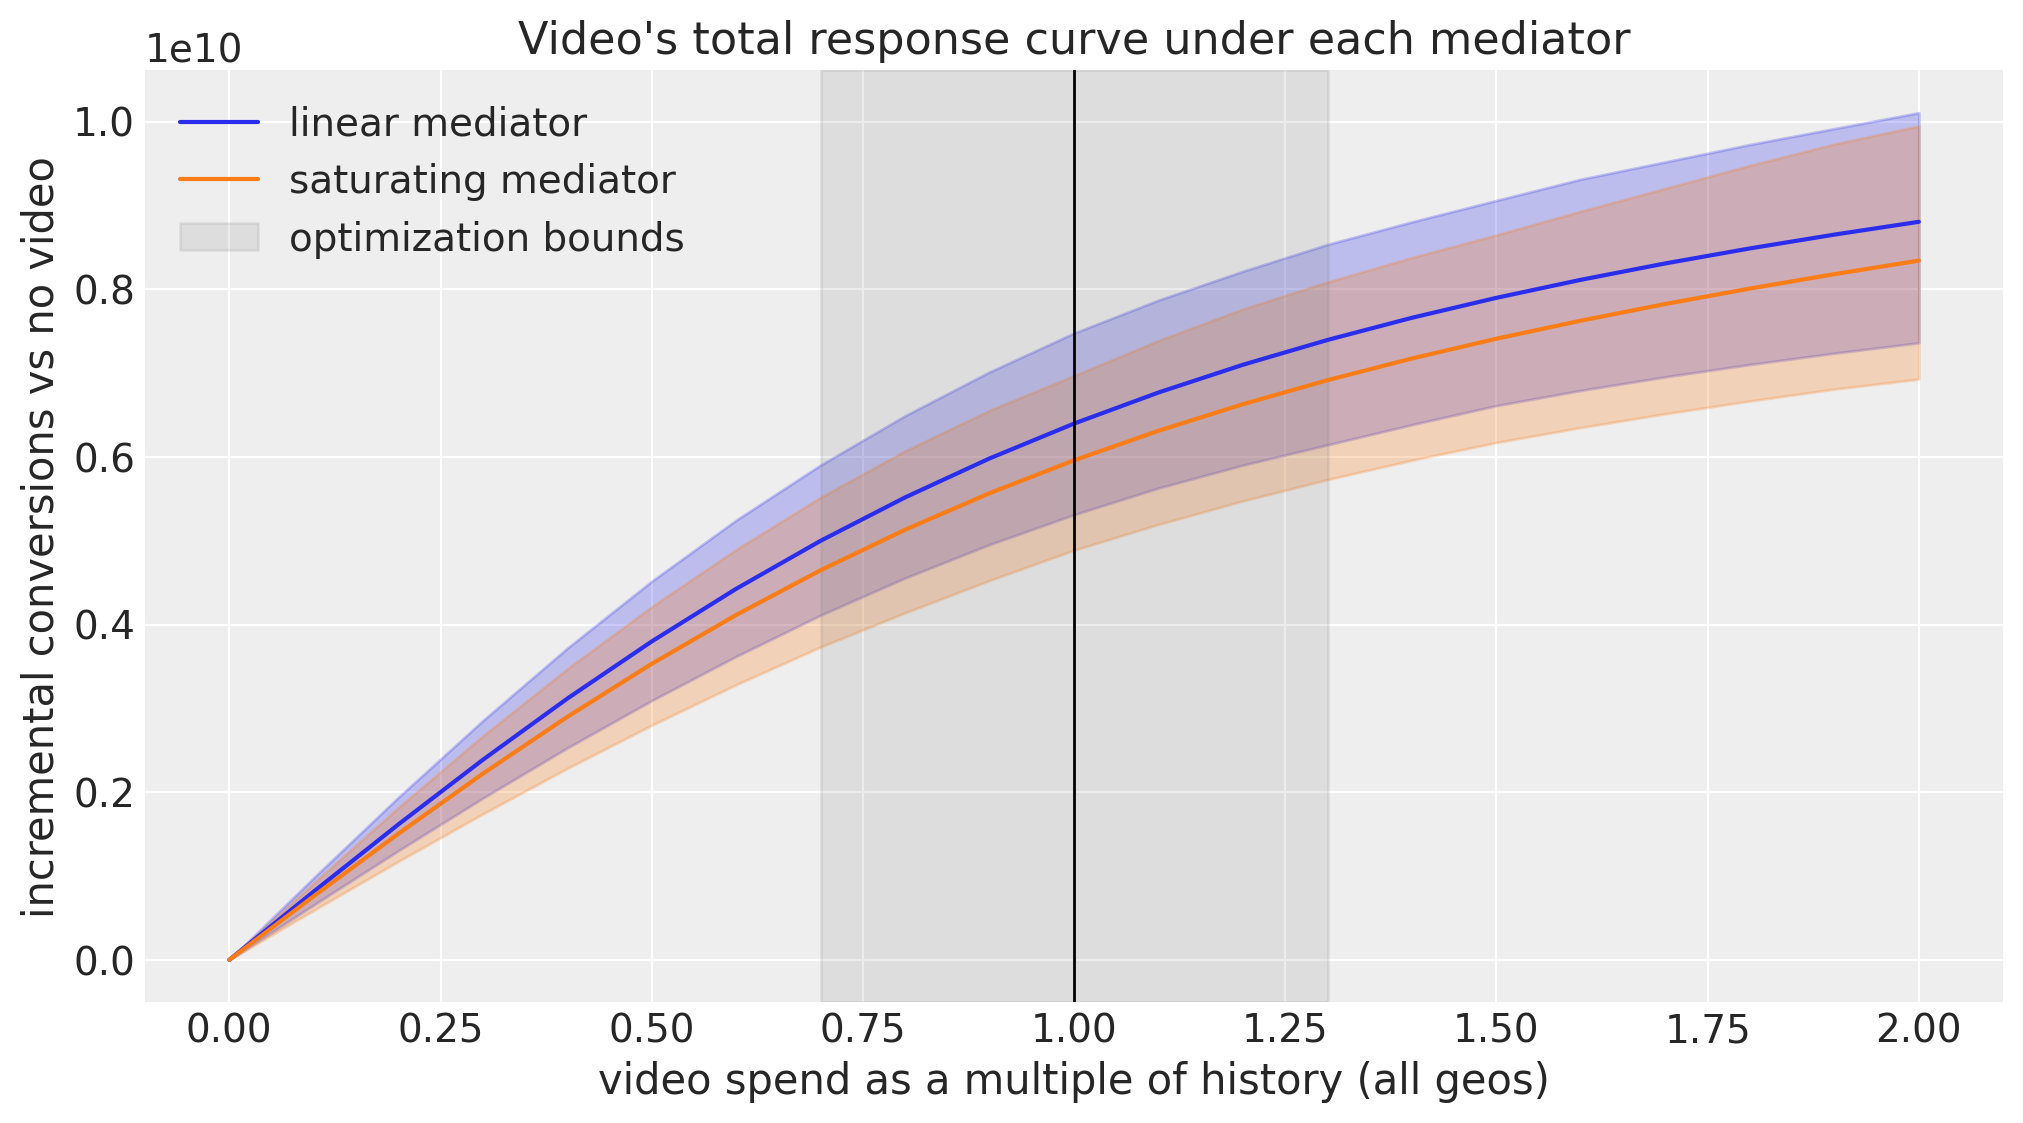

In [24]:
scales = np.linspace(0.0, 2.0, 21)


def video_curve(optimizer: BudgetOptimizer) -> xr.DataArray:
    """Per-draw total response to scaled video spend, relative to no video."""
    zero = response_samples(optimizer, video_off, "total")
    curve = []
    for s in scales:
        plan = mean_plan.copy()
        plan.loc[{"channel": "video"}] = s * mean_plan.sel(channel="video")
        curve.append(response_samples(optimizer, plan, "total") - zero)
    return xr.concat(curve, dim=pd.Index(scales, name="scale"))


fig, ax = plt.subplots(figsize=(10, 5.5))
for label, color in [("linear", "C0"), ("saturating", "C1")]:
    curve = video_curve(optimizers[label])
    lo = curve.quantile(0.03, dim="sample")
    hi = curve.quantile(0.97, dim="sample")
    ax.fill_between(scales, lo, hi, color=color, alpha=0.25)
    ax.plot(scales, curve.mean("sample"), color=color, label=f"{label} mediator")
ax.axvspan(0.7, 1.3, color="gray", alpha=0.15, label="optimization bounds")
ax.axvline(1.0, color="black", linewidth=1)
ax.set(
    xlabel="video spend as a multiple of history (all geos)",
    ylabel="incremental conversions vs no video",
    title="Video's total response curve under each mediator",
)
ax.legend(loc="upper left")

CURVE_PLACEHOLDER

## Caveats

- **In-sample optimization.** As in {ref}`mmm_funnel_mueffect_advanced`, the plans are optimized and scored over the training window, with the historical weekly pattern kept fixed. The end of the window carries truncated carry-over, so these are in-sample optima, not steady-state ones.
- **The plug-in is a stylized shortcut.** Fixing the brand-lift parameters at their means while keeping the rest of the joint posterior isolates the first-stage uncertainty. A real two-stage fit would also re-estimate the second stage conditional on the plug-in, which is a different, usually smaller, posterior again.
- **One synthetic dataset.** Meridian's data are simulated, and we do not have the generating parameters, so nothing here is scored against a known truth. The comparisons are about what each formulation lets the posterior express, not about which recovers the truth better.
- **Brand residuals are held fixed.** The brand counterfactual keeps the unexplained part of branded search at its observed value under every plan. That is the same convention as Meridian's analyzer and the natural one for in-sample planning.
- **Spend, not impressions; conversions, not revenue.** Both are modeling choices made for simplicity and do not affect the structure of the comparison.

## References

- Google Meridian, [Full-funnel MMM: unifying upper-funnel and lower-funnel measurement](https://developers.google.com/meridian/docs/advanced-modeling/full-funnel).
- Google Meridian, [Full-funnel MMM walkthrough notebook](https://github.com/google/meridian/blob/main/demo/Meridian_Full_Funnel.ipynb).
- {ref}`mmm_funnel_mueffect` and {ref}`mmm_funnel_mueffect_advanced` for the `MuEffect` funnel pattern and funnel-aware budget optimization.

In [25]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Fri, 02 Oct 2026

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.15.0

pymc_marketing: 1.2.0
pytensor      : 3.0.7

arviz         : 1.2.0
arviz_plots   : 1.2.0
graphviz      : 0.21
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pydantic      : 2.13.4
pymc          : 6.0.1
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.2.0
pytensor      : 3.0.7
scipy         : 1.15.3
xarray        : 2026.4.0

Watermark: 2.6.0

